In [3]:
# ===============================
# Laptop Price Prediction Project
# Import Required Libraries
# ===============================

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

import pickle
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Set display options

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [3]:
# Load the dataset

df = pd.read_csv("laptop_data.csv")

df.head()

,Company,TypeName,Inches,Ram,Weight,Price,Touchscreen,IPS,PPI,SSD,HDD,Hybrid,Flash_Storage,CPU_Brand,CPU_Speed,GPU_Brand,OS_Category
0,Apple,Ultrabook,13.3,8,1.37,2.413747,0,1,226.983005,128,0,0,0,Intel Core i5,2.3,Intel,Mac
1,Apple,Ultrabook,13.3,8,1.34,2.377394,0,0,127.677940,0,0,0,128,Intel Core i5,1.8,Intel,Mac
2,HP,Notebook,15.6,8,1.86,2.335046,0,0,141.211998,256,0,0,0,Intel Core i5,2.5,Intel,Other
3,Apple,Ultrabook,15.4,16,1.83,2.469326,0,1,220.534624,512,0,0,0,Intel Core i7,2.7,AMD,Mac
4,Apple,Ultrabook,13.3,8,1.37,2.440005,0,1,226.983005,256,0,0,0,Intel Core i5,3.1,Intel,Mac


In [4]:
# Check the shape of the dataset

print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 1273
Columns : 17


In [5]:
# Display information about the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1273 entries, 0 to 1272
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Company        1273 non-null   object 
 1   TypeName       1273 non-null   object 
 2   Inches         1273 non-null   float64
 3   Ram            1273 non-null   int64  
 4   Weight         1273 non-null   float64
 5   Price          1273 non-null   float64
 6   Touchscreen    1273 non-null   int64  
 7   IPS            1273 non-null   int64  
 8   PPI            1273 non-null   float64
 9   SSD            1273 non-null   int64  
 10  HDD            1273 non-null   int64  
 11  Hybrid         1273 non-null   int64  
 12  Flash_Storage  1273 non-null   int64  
 13  CPU_Brand      1273 non-null   object 
 14  CPU_Speed      1273 non-null   float64
 15  GPU_Brand      1273 non-null   object 
 16  OS_Category    1273 non-null   object 
dtypes: float64(5), int64(7), object(5)
memory usage: 169

In [6]:
# Display statistical summary

df.describe(include='all')

,Company,TypeName,Inches,Ram,Weight,Price,Touchscreen,IPS,PPI,SSD,HDD,Hybrid,Flash_Storage,CPU_Brand,CPU_Speed,GPU_Brand,OS_Category
count,1273,1273,1273.000000,1273.000000,1273.000000,1273.000000,1273.000000,1273.000000,1273.000000,1273.000000,1273.000000,1273.000000,1273.000000,1273,1273.000000,1273,1273
unique,19,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,NaN,4,5
top,Dell,Notebook,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Intel Core i7,NaN,Intel,Windows
freq,291,705,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,515,NaN,702,1099
mean,NaN,NaN,15.023802,8.447761,2.041060,2.380458,0.147683,0.280440,147.004917,186.454046,421.659073,7.638649,4.512176,NaN,2.303535,NaN,NaN
std,NaN,NaN,1.429685,5.098771,0.669292,0.057713,0.354925,0.449391,42.993693,187.928591,530.168610,86.969279,30.511804,NaN,0.503856,NaN,NaN
min,NaN,NaN,10.100000,2.000000,0.690000,2.212071,0.000000,0.000000,90.583402,0.000000,0.000000,0.000000,0.000000,NaN,0.900000,NaN,NaN
25%,NaN,NaN,14.000000,4.000000,1.500000,2.340592,0.000000,0.000000,127.335675,0.000000,0.000000,0.000000,0.000000,NaN,2.000000,NaN,NaN
50%,NaN,NaN,15.600000,8.000000,2.040000,2.386214,0.000000,0.000000,141.211998,256.000000,0.000000,0.000000,0.000000,NaN,2.500000,NaN,NaN
75%,NaN,NaN,15.600000,8.000000,2.310000,2.423691,0.000000,1.000000,157.350512,256.000000,1024.000000,0.000000,0.000000,NaN,2.700000,NaN,NaN


In [7]:
# Check the first 10 rows

df.head(10)

,Company,TypeName,Inches,Ram,Weight,Price,Touchscreen,IPS,PPI,SSD,HDD,Hybrid,Flash_Storage,CPU_Brand,CPU_Speed,GPU_Brand,OS_Category
0,Apple,Ultrabook,13.3,8,1.37,2.413747,0,1,226.983005,128,0,0,0,Intel Core i5,2.3,Intel,Mac
1,Apple,Ultrabook,13.3,8,1.34,2.377394,0,0,127.677940,0,0,0,128,Intel Core i5,1.8,Intel,Mac
2,HP,Notebook,15.6,8,1.86,2.335046,0,0,141.211998,256,0,0,0,Intel Core i5,2.5,Intel,Other
3,Apple,Ultrabook,15.4,16,1.83,2.469326,0,1,220.534624,512,0,0,0,Intel Core i7,2.7,AMD,Mac
4,Apple,Ultrabook,13.3,8,1.37,2.440005,0,1,226.983005,256,0,0,0,Intel Core i5,3.1,Intel,Mac
5,Acer,Notebook,15.6,4,2.10,2.299282,0,0,100.454670,0,500,0,0,AMD Processor,3.0,AMD,Windows
6,Apple,Ultrabook,15.4,16,2.04,2.454800,0,1,220.534624,0,0,0,256,Intel Core i7,2.2,Intel,Mac
7,Apple,Ultrabook,13.3,8,1.34,2.400675,0,0,127.677940,0,0,0,256,Intel Core i5,1.8,Intel,Mac
8,Asus,Ultrabook,14.0,16,1.30,2.423514,0,0,157.350512,512,0,0,0,Intel Core i7,1.8,Nvidia,Windows
9,Acer,Ultrabook,14.0,8,1.60,2.362923,0,1,157.350512,256,0,0,0,Intel Core i5,1.6,Intel,Windows


In [8]:
# Check the last 10 rows

df.tail(10)

,Company,TypeName,Inches,Ram,Weight,Price,Touchscreen,IPS,PPI,SSD,HDD,Hybrid,Flash_Storage,CPU_Brand,CPU_Speed,GPU_Brand,OS_Category
1263,Dell,Notebook,15.6,2,2.20,2.293857,0,0,100.454670,0,500,0,0,Other Intel Processor,1.6,Intel,Windows
1264,Lenovo,Notebook,15.6,8,2.60,2.377400,0,1,141.211998,0,1024,0,0,Intel Core i7,2.6,Nvidia,Windows
1265,HP,Notebook,15.6,6,2.04,2.330731,0,0,141.211998,0,0,1024,0,AMD Processor,2.9,AMD,Windows
1266,Dell,Notebook,15.6,8,2.30,2.367214,0,0,100.454670,0,1024,0,0,Intel Core i7,2.7,AMD,Linux
1267,HP,Netbook,11.6,2,1.17,2.231937,0,0,135.094211,0,0,0,32,Other Intel Processor,1.6,Intel,Windows
1268,Asus,Notebook,15.6,4,2.20,2.356624,0,0,100.454670,0,500,0,0,Intel Core i7,2.5,Nvidia,Windows
1269,Lenovo,2 in 1 Convertible,14.0,4,1.80,2.345060,1,1,157.350512,128,0,0,0,Intel Core i7,2.5,Intel,Windows
1270,Lenovo,2 in 1 Convertible,13.3,16,1.30,2.423750,1,1,276.053530,512,0,0,0,Intel Core i7,2.5,Intel,Windows
1271,Lenovo,Notebook,14.0,2,1.50,2.241697,0,0,111.935204,0,0,0,64,Other Intel Processor,1.6,Intel,Windows
1272,HP,Notebook,15.6,6,2.19,2.362186,0,0,100.454670,0,1024,0,0,Intel Core i7,2.5,AMD,Windows


In [9]:
# Display all column names

df.columns

Index(['Company', 'TypeName', 'Inches', 'Ram', 'Weight', 'Price',
       'Touchscreen', 'IPS', 'PPI', 'SSD', 'HDD', 'Hybrid', 'Flash_Storage',
       'CPU_Brand', 'CPU_Speed', 'GPU_Brand', 'OS_Category'],
      dtype='object')

In [10]:
# Check the data type of each column

df.dtypes


Company           object
TypeName          object
Inches           float64
Ram                int64
Weight           float64
Price            float64
Touchscreen        int64
IPS                int64
PPI              float64
SSD                int64
HDD                int64
Hybrid             int64
Flash_Storage      int64
CPU_Brand         object
CPU_Speed        float64
GPU_Brand         object
OS_Category       object
dtype: object

In [11]:
# Check for missing values

df.isnull().sum()

Company          0
TypeName         0
Inches           0
Ram              0
Weight           0
Price            0
Touchscreen      0
IPS              0
PPI              0
SSD              0
HDD              0
Hybrid           0
Flash_Storage    0
CPU_Brand        0
CPU_Speed        0
GPU_Brand        0
OS_Category      0
dtype: int64

In [12]:
# Check duplicate rows

df.duplicated().sum()

np.int64(0)

In [13]:
# Remove duplicate rows (if any)

df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (1273, 17)


In [14]:
# Check dataset again

df.head()

,Company,TypeName,Inches,Ram,Weight,Price,Touchscreen,IPS,PPI,SSD,HDD,Hybrid,Flash_Storage,CPU_Brand,CPU_Speed,GPU_Brand,OS_Category
0,Apple,Ultrabook,13.3,8,1.37,2.413747,0,1,226.983005,128,0,0,0,Intel Core i5,2.3,Intel,Mac
1,Apple,Ultrabook,13.3,8,1.34,2.377394,0,0,127.677940,0,0,0,128,Intel Core i5,1.8,Intel,Mac
2,HP,Notebook,15.6,8,1.86,2.335046,0,0,141.211998,256,0,0,0,Intel Core i5,2.5,Intel,Other
3,Apple,Ultrabook,15.4,16,1.83,2.469326,0,1,220.534624,512,0,0,0,Intel Core i7,2.7,AMD,Mac
4,Apple,Ultrabook,13.3,8,1.37,2.440005,0,1,226.983005,256,0,0,0,Intel Core i5,3.1,Intel,Mac


In [15]:
# Check unique values in each column

for column in df.columns:
    print(f"{column} : {df[column].nunique()}")

Company : 19
TypeName : 6
Inches : 18
Ram : 9
Weight : 171
Price : 791
Touchscreen : 2
IPS : 2
PPI : 39
SSD : 12
HDD : 6
Hybrid : 3
Flash_Storage : 7
CPU_Brand : 5
CPU_Speed : 25
GPU_Brand : 4
OS_Category : 5


In [16]:
# Display all column names

df.columns

Index(['Company', 'TypeName', 'Inches', 'Ram', 'Weight', 'Price',
       'Touchscreen', 'IPS', 'PPI', 'SSD', 'HDD', 'Hybrid', 'Flash_Storage',
       'CPU_Brand', 'CPU_Speed', 'GPU_Brand', 'OS_Category'],
      dtype='object')

In [17]:
# Display the numerical summary

df.describe()

,Inches,Ram,Weight,Price,Touchscreen,IPS,PPI,SSD,HDD,Hybrid,Flash_Storage,CPU_Speed
count,1273.000000,1273.000000,1273.000000,1273.000000,1273.000000,1273.000000,1273.000000,1273.000000,1273.000000,1273.000000,1273.000000,1273.000000
mean,15.023802,8.447761,2.041060,2.380458,0.147683,0.280440,147.004917,186.454046,421.659073,7.638649,4.512176,2.303535
std,1.429685,5.098771,0.669292,0.057713,0.354925,0.449391,42.993693,187.928591,530.168610,86.969279,30.511804,0.503856
min,10.100000,2.000000,0.690000,2.212071,0.000000,0.000000,90.583402,0.000000,0.000000,0.000000,0.000000,0.900000
25%,14.000000,4.000000,1.500000,2.340592,0.000000,0.000000,127.335675,0.000000,0.000000,0.000000,0.000000,2.000000
50%,15.600000,8.000000,2.040000,2.386214,0.000000,0.000000,141.211998,256.000000,0.000000,0.000000,0.000000,2.500000
75%,15.600000,8.000000,2.310000,2.423691,0.000000,1.000000,157.350512,256.000000,1024.000000,0.000000,0.000000,2.700000
max,18.400000,64.000000,4.700000,2.540928,1.000000,1.000000,352.465147,1024.000000,2048.000000,1024.000000,512.000000,3.600000


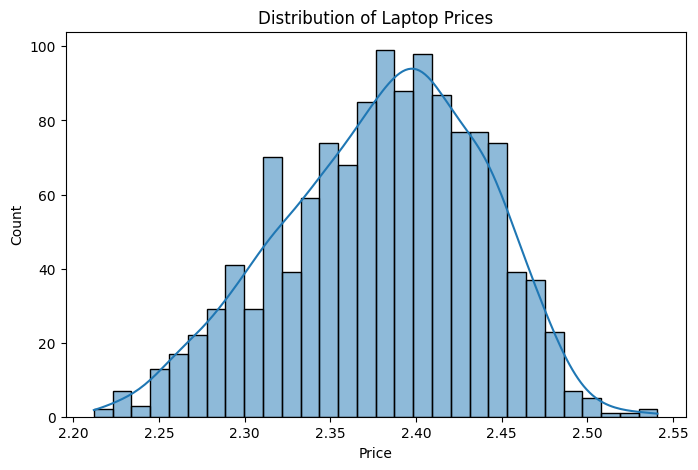

In [18]:
# Price distribution

plt.figure(figsize=(8,5))

sns.histplot(df["Price"], bins=30, kde=True)

plt.title("Distribution of Laptop Prices")
plt.xlabel("Price")
plt.ylabel("Count")

plt.show()

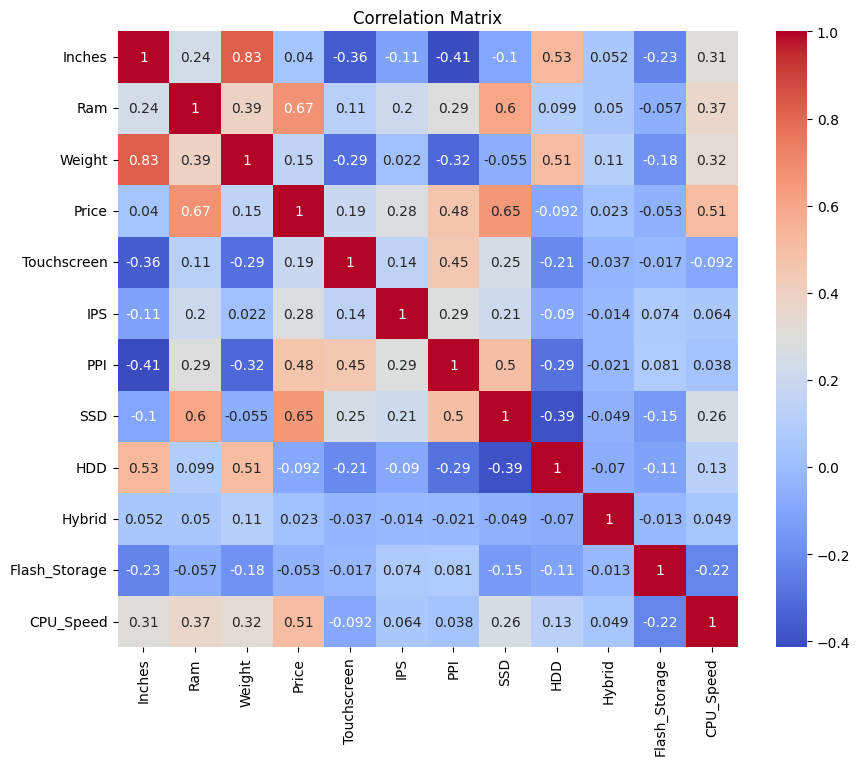

In [19]:
# Correlation between numerical features

plt.figure(figsize=(10,8))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Matrix")

plt.show()

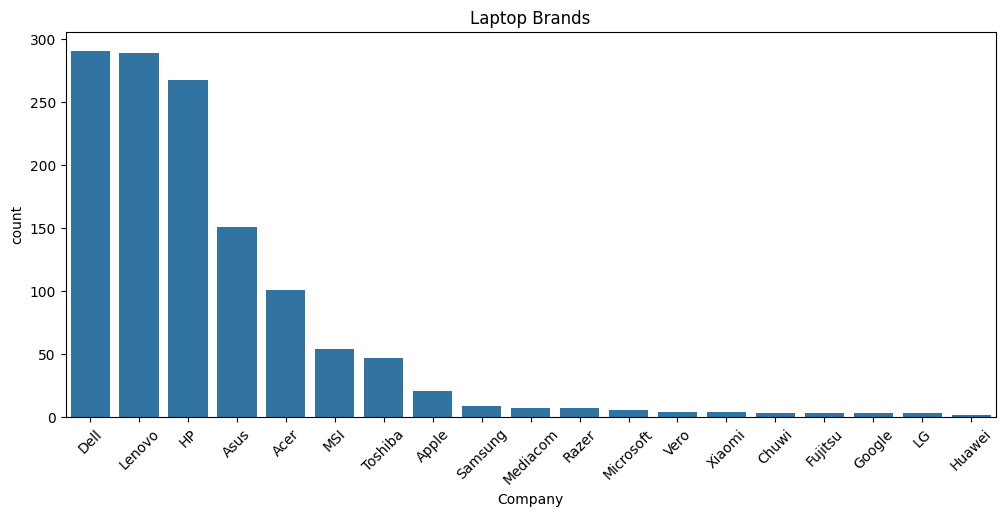

In [20]:
# Laptop companies

plt.figure(figsize=(12,5))

sns.countplot(data=df,
              x="Company",
              order=df["Company"].value_counts().index)

plt.xticks(rotation=45)

plt.title("Laptop Brands")

plt.show()

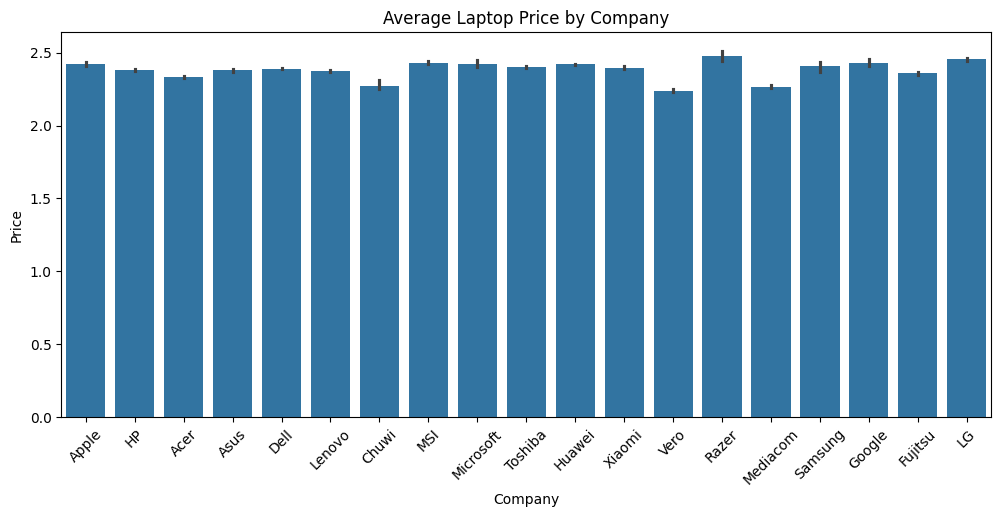

In [21]:
# Average price by company

plt.figure(figsize=(12,5))

sns.barplot(data=df,
            x="Company",
            y="Price")

plt.xticks(rotation=45)

plt.title("Average Laptop Price by Company")

plt.show()

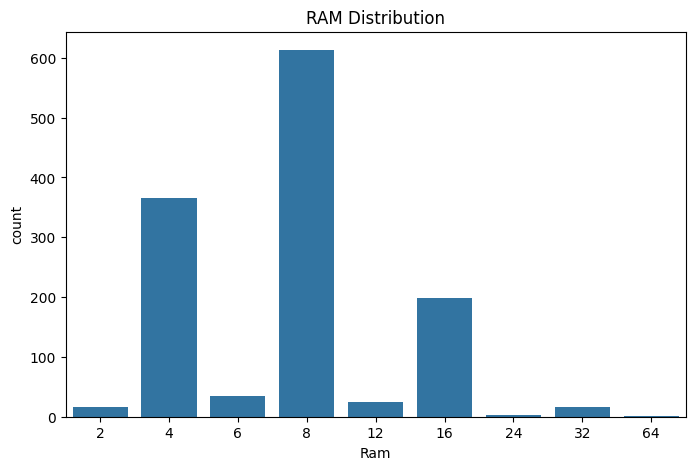

In [22]:
# RAM distribution

plt.figure(figsize=(8,5))

sns.countplot(data=df,
              x="Ram")

plt.title("RAM Distribution")

plt.show()

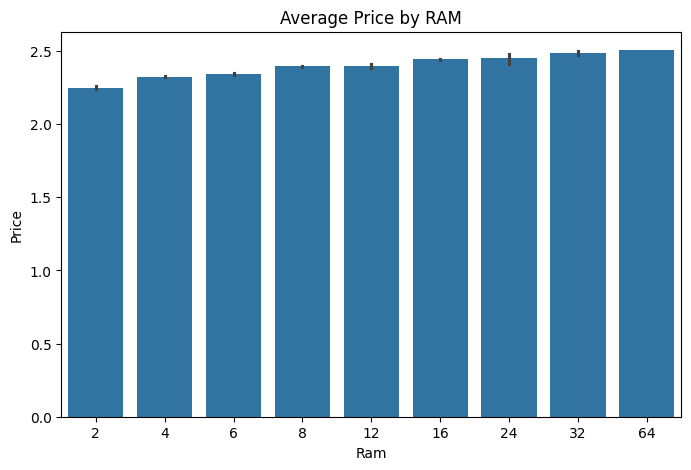

In [23]:
# Average price according to RAM

plt.figure(figsize=(8,5))

sns.barplot(data=df,
            x="Ram",
            y="Price")

plt.title("Average Price by RAM")

plt.show()

In [24]:
# Separate input features and target variable

X = df.drop("Price", axis=1)
y = df["Price"]

In [25]:
# Convert categorical features into numerical format

categorical_columns = X.select_dtypes(include="object").columns

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns)
    ],
    remainder="passthrough"
)

In [26]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples :", X_train.shape[0])
print("Testing samples  :", X_test.shape[0])

Training samples : 1018
Testing samples  : 255


In [27]:
# Train Linear Regression model

linear_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)

linear_prediction = linear_model.predict(X_test)

In [28]:
# Evaluate Linear Regression

print("Linear Regression")
print("R2 Score :", r2_score(y_test, linear_prediction))
print("MAE      :", mean_absolute_error(y_test, linear_prediction))
print("RMSE     :", np.sqrt(mean_squared_error(y_test, linear_prediction)))

Linear Regression
R2 Score : 0.8176052586631949
MAE      : 0.01883788943919398
RMSE     : 0.024534783828184685


In [29]:
# Train Decision Tree model

decision_tree = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeRegressor(random_state=42))
])

decision_tree.fit(X_train, y_train)

decision_prediction = decision_tree.predict(X_test)

In [30]:
# Evaluate Decision Tree model

print("Decision Tree Regression")
print("R2 Score :", r2_score(y_test, decision_prediction))
print("MAE      :", mean_absolute_error(y_test, decision_prediction))
print("RMSE     :", np.sqrt(mean_squared_error(y_test, decision_prediction)))

Decision Tree Regression
R2 Score : 0.8460134526227845
MAE      : 0.017424997848112935
RMSE     : 0.022543298940502686


In [31]:
# Train Random Forest model

random_forest = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ))
])

random_forest.fit(X_train, y_train)

random_prediction = random_forest.predict(X_test)

In [32]:
# Evaluate Random Forest model

print("Random Forest Regression")
print("R2 Score :", r2_score(y_test, random_prediction))
print("MAE      :", mean_absolute_error(y_test, random_prediction))
print("RMSE     :", np.sqrt(mean_squared_error(y_test, random_prediction)))

Random Forest Regression
R2 Score : 0.9046763447885047
MAE      : 0.013597612235782076
RMSE     : 0.017736847129513147


In [33]:
# Train XGBoost model

xgb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(
        n_estimators=1000,
        learning_rate=0.03,
        max_depth=8,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ))
])

xgb_model.fit(X_train, y_train)

xgb_prediction = xgb_model.predict(X_test)

In [34]:
# Evaluate XGBoost model

print("XGBoost Regression")
print("R2 Score :", r2_score(y_test, xgb_prediction))
print("MAE      :", mean_absolute_error(y_test, xgb_prediction))
print("RMSE     :", np.sqrt(mean_squared_error(y_test, xgb_prediction)))

XGBoost Regression
R2 Score : 0.9208260644785107
MAE      : 0.012597604502127003
RMSE     : 0.016164683136912873


In [35]:
# Compare model performance

results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "R2 Score": [
        r2_score(y_test, linear_prediction),
        r2_score(y_test, decision_prediction),
        r2_score(y_test, random_prediction),
        r2_score(y_test, xgb_prediction)
    ],
    "MAE": [
        mean_absolute_error(y_test, linear_prediction),
        mean_absolute_error(y_test, decision_prediction),
        mean_absolute_error(y_test, random_prediction),
        mean_absolute_error(y_test, xgb_prediction)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, linear_prediction)),
        np.sqrt(mean_squared_error(y_test, decision_prediction)),
        np.sqrt(mean_squared_error(y_test, random_prediction)),
        np.sqrt(mean_squared_error(y_test, xgb_prediction))
    ]
})

results.sort_values("R2 Score", ascending=False)

,Model,R2 Score,MAE,RMSE
3,XGBoost,0.920826,0.012598,0.016165
2,Random Forest,0.904676,0.013598,0.017737
1,Decision Tree,0.846013,0.017425,0.022543
0,Linear Regression,0.817605,0.018838,0.024535


In [36]:
# Train the final model using the complete dataset

final_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(
        n_estimators=1000,
        learning_rate=0.03,
        max_depth=8,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ))
])

final_model.fit(X, y)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [41]:
# Save the trained model

with open("xgb_model.pk2", "wb") as file:
    pickle.dump(final_model, file)

print("Model saved successfully.")

Model saved successfully.


In [42]:
# Save feature names

feature_columns = X.columns.tolist()

with open("columns.pk2", "wb") as file:
    pickle.dump(feature_columns, file)

print("Feature columns saved successfully.")

Feature columns saved successfully.


In [5]:
# Load the saved model

with open("xgb_model.pk2", "rb") as file:
    loaded_model = pickle.load(file)

print("Model loaded successfully.")

Model loaded successfully.


In [44]:
# Test prediction using a sample from the dataset

sample = X.iloc[[0]]

prediction = loaded_model.predict(sample)

print("Predicted Price :", prediction[0])
print("Actual Price    :", y.iloc[0])

Predicted Price : 2.413577
Actual Price    : 2.4137466593950823


In [45]:
df["Price"].head()

0    2.413747
1    2.377394
2    2.335046
3    2.469326
4    2.440005
Name: Price, dtype: float64

In [46]:
df["Price"].describe()

count    1273.000000
mean        2.380458
std         0.057713
min         2.212071
25%         2.340592
50%         2.386214
75%         2.423691
max         2.540928
Name: Price, dtype: float64

In [ ]:
## Testing the Saved Model

The target variable (Price) was transformed before training to improve model stability and reduce skewness.

Therefore, the model predicts the transformed price values.

These transformed values are converted back to the original price (INR) in the deployment application before being displayed to the user.

In [48]:
df["Price"].head()

0    2.413747
1    2.377394
2    2.335046
3    2.469326
4    2.440005
Name: Price, dtype: float64

In [51]:
np.log(df["Price"])

0       0.881180
1       0.866005
2       0.848031
3       0.903945
4       0.892000
          ...   
1268    0.857230
1269    0.852311
1270    0.885316
1271    0.807233
1272    0.859587
Name: Price, Length: 1273, dtype: float64

In [52]:
print(df["Price"].head())

0    2.413747
1    2.377394
2    2.335046
3    2.469326
4    2.440005
Name: Price, dtype: float64


In [53]:
print(np.exp(df["Price"].head()))

0    11.175755
1    10.776777
2    10.329931
3    11.814476
4    11.473101
Name: Price, dtype: float64


In [54]:
print(np.exp(np.exp(df["Price"].head())))

0     71378.6832
1     47895.5232
2     30636.0000
3    135195.3360
4     96095.8080
Name: Price, dtype: float64


In [55]:
print(df["Price"].min())
print(df["Price"].max())

2.2120711884494746
2.540927839386229


In [56]:
# Test the saved model

sample = X.iloc[[0]]

prediction = loaded_model.predict(sample)[0]

predicted_price = np.exp(np.exp(prediction))
actual_price = np.exp(np.exp(y.iloc[0]))

print(f"Predicted Price : ₹{predicted_price:,.0f}")
print(f"Actual Price    : ₹{actual_price:,.0f}")

Predicted Price : ₹71,244
Actual Price    : ₹71,379


In [57]:
# Test the saved model

sample = X.iloc[[0]]

prediction = loaded_model.predict(sample)[0]

predicted_price = np.exp(np.exp(prediction))
actual_price = np.exp(np.exp(y.iloc[0]))

print(f"Predicted Price : ₹{predicted_price:,.0f}")
print(f"Actual Price    : ₹{actual_price:,.0f}")


Predicted Price : ₹71,244
Actual Price    : ₹71,379


In [ ]:
### Observation

The predicted laptop price is very close to the actual price.
The difference between the predicted and actual value is only ₹135, indicating that the trained XGBoost model has learned the relationship between laptop specifications and price effectively.

In [1]:
import os

print(os.getcwd())

C:\Users\user\DATA SCIENCE\Smart Laptop Price Prediction & Recommendation System
